In [ ]:
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
display(df.describe())

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


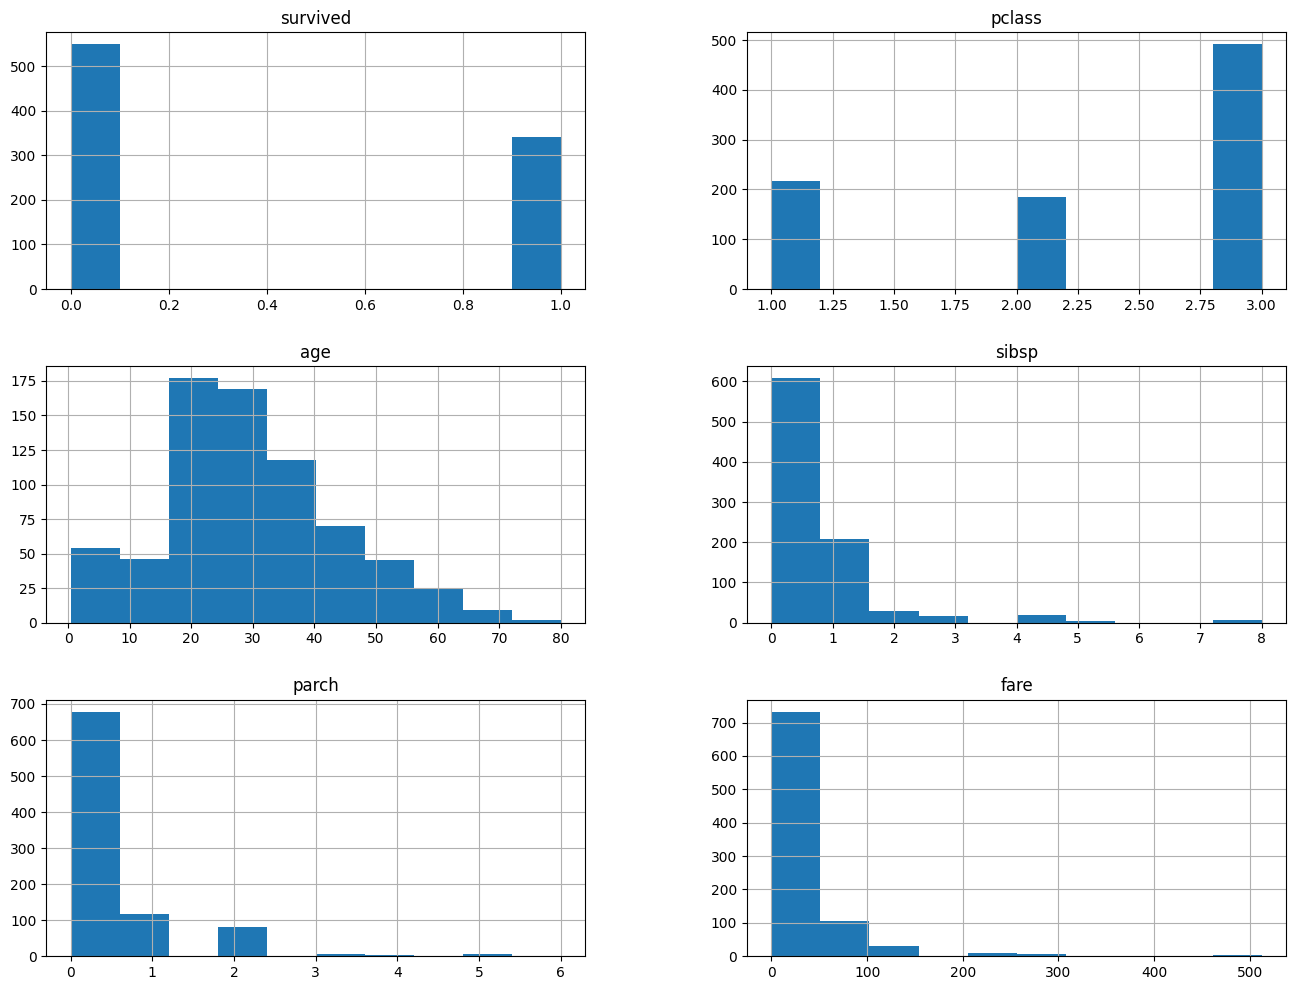

In [ ]:
df.hist(figsize=(16,12))
plt.show()

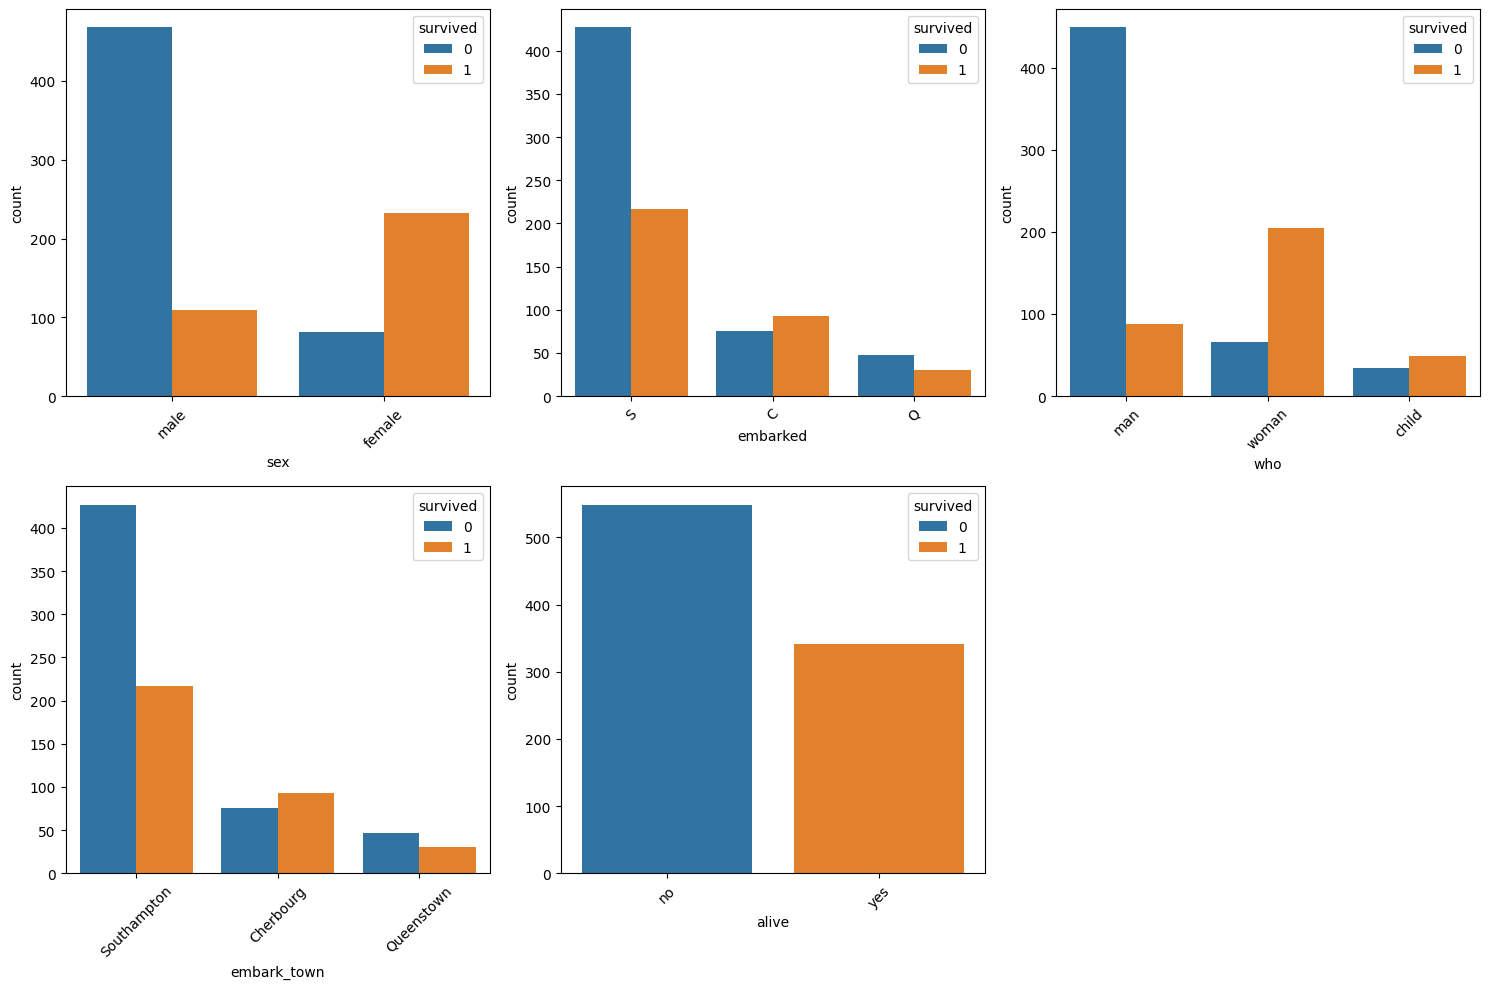

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_cols):
    plt.subplot((len(cat_cols)//3)+1, 3, i+1)
    sns.countplot(data=df, x=col, hue='survived')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

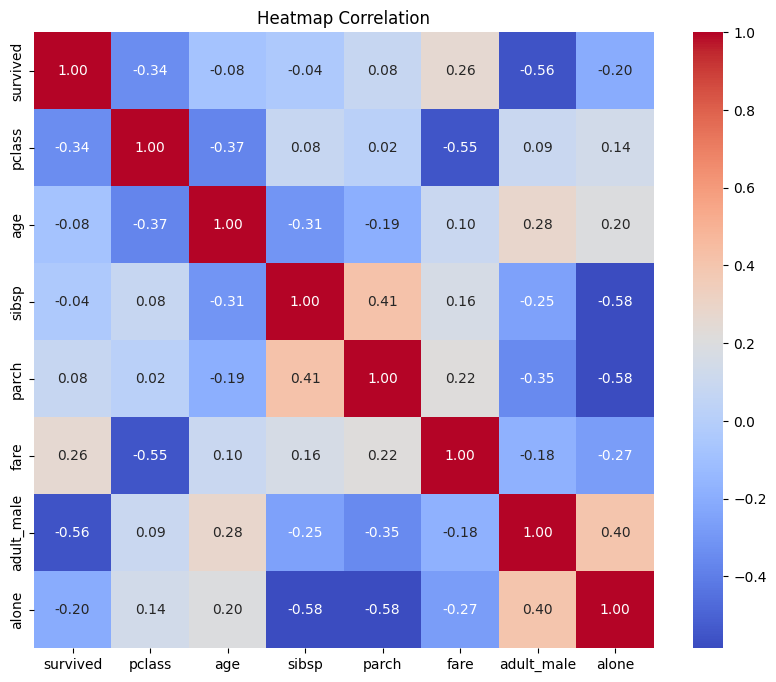

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Correlation")
plt.show()

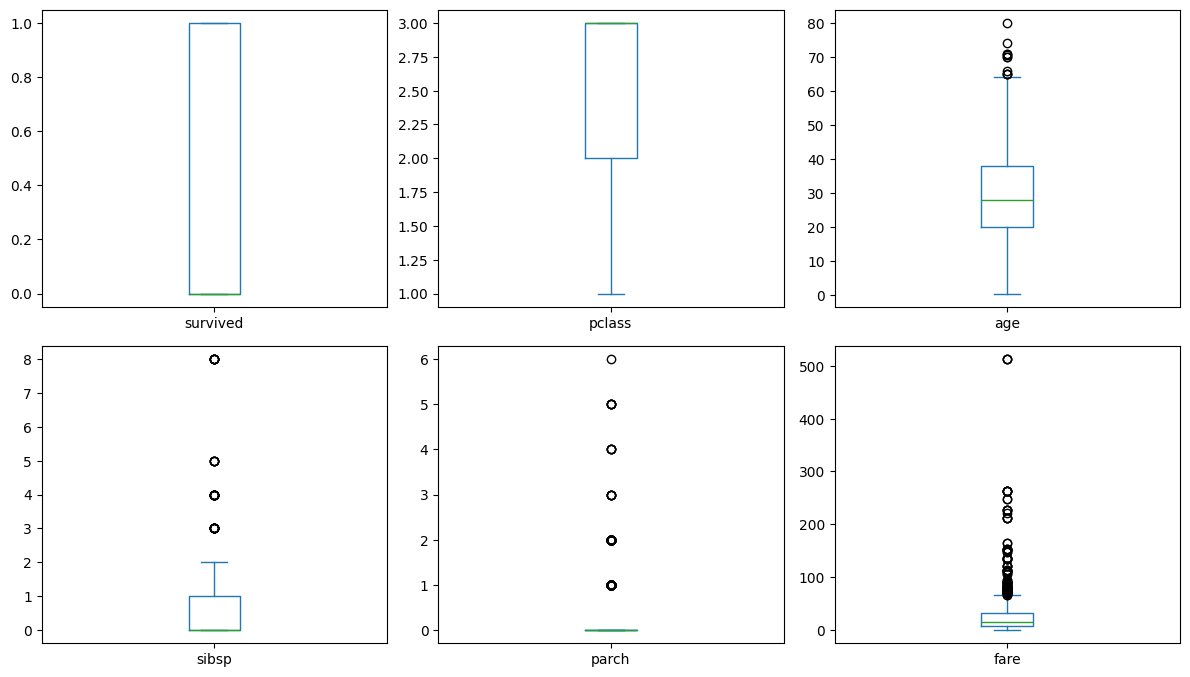

In [ ]:
df.select_dtypes(include=np.number).plot(kind='box', subplots=True, layout=(3,3), figsize=(12,10))
plt.tight_layout()
plt.show()

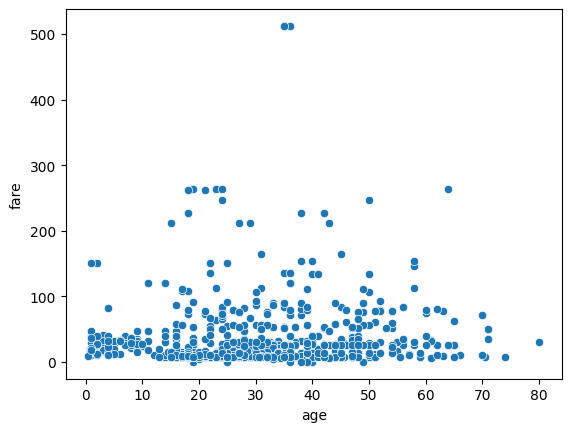

In [ ]:
sns.scatterplot(data=df, x='age', y='fare')
plt.show()

## Key Insights from EDA

1. Female passengers had significantly higher survival rates.
2. First-class passengers survived more than third-class.
3. Higher fare correlates with higher survival probability.
4. Children had better survival chances than older adults.


In [ ]:
df_processed = df.copy()

In [ ]:
df_processed.isnull().sum()


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


## Missing Values Strategy

After analyzing the dataset, I found missing values in several columns:
- `age`: 177 missing values
- `embarked`: 2 missing values  
- `deck`: 688 missing values (77% missing!)

**My strategy:**

1. **Numerical columns (age, fare):** Fill with **median**
   - Why median? Because it's robust to outliers. The Titanic dataset has outliers in fare prices, so median is better than mean.
   
2. **Categorical columns (embarked, embark_town):** Fill with **mode** (most frequent value)
   - Why mode? For categorical data, using the most common category preserves the distribution and makes logical sense (e.g., most passengers embarked from Southampton).

3. **Drop `deck` column:**
   - Why drop? 688 out of 891 rows (77%) are missing. Imputing this much missing data would introduce too much bias and unreliable predictions. It's better to remove it entirely.

In [ ]:
num_cols = df_processed.select_dtypes(include=np.number).columns
cat_cols = df_processed.select_dtypes(include='object').columns

df_processed[num_cols] = df_processed[num_cols].fillna(df_processed[num_cols].median())

for col in cat_cols:
    df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

/tmp/ipython-input-5011750.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)


In [ ]:
df_processed.isnull().sum()


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [ ]:
df_processed.drop(columns=['deck'], axis=1, inplace=True)
df_processed.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## Categorical Encoding Strategy

I used **Label Encoding** for all categorical features (`sex`, `embarked`, `class`, `who`, `adult_male`, `embark_town`, `alive`, `alone`).

**Why Label Encoding?**
- **Simplicity:** Label Encoding converts categories into numerical values (0, 1, 2, ...), making it compatible with machine learning algorithms.
- **Binary features:** Features like `sex` (male/female), `adult_male` (True/False), and `alive` (yes/no) only have 2 categories, so Label Encoding works well.
- **Tree-based models:** If we plan to use Decision Trees or Random Forest for prediction, Label Encoding is sufficient because these models can handle ordinal-like encodings.

**Alternative consideration:**
- One-Hot Encoding could be used for nominal features like `embarked` (S/C/Q) to avoid implying order, but it would create more columns and increase dimensionality. For this dataset size (891 rows), Label Encoding is more efficient.

In [ ]:
label_encoder_cols = ['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

for col in label_encoder_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])

df_processed.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,1,2,0,0
1,1,1,0,38.0,1,0,71.2833,0,0,2,0,0,1,0
2,1,3,0,26.0,0,0,7.9250,2,2,2,0,2,1,1
3,1,1,0,35.0,1,0,53.1000,2,0,2,0,2,1,0
4,0,3,1,35.0,0,0,8.0500,2,2,1,1,2,0,1


## Normalization Strategy: MinMaxScaler

I used **MinMaxScaler** to normalize numerical features (`age`, `sibsp`, `parch`, `fare`).

**Why MinMaxScaler?**
- **Scale to [0,1] range:** MinMaxScaler transforms all features to the same scale (0 to 1), which is important for algorithms sensitive to feature magnitude (e.g., Logistic Regression, Neural Networks, KNN).
- **Preserves distribution:** Unlike StandardScaler (which assumes normal distribution), MinMaxScaler works well even if data is not normally distributed.
- **Better for bounded features:** Features like `sibsp` and `parch` are already small integers, so scaling to [0,1] is more intuitive than z-score standardization.

**When to use StandardScaler instead:**
- If the data has many outliers, StandardScaler might be better because it's less sensitive to extreme values.
- For our dataset, I checked the box plots and outliers in `fare` exist, but MinMaxScaler still works well for the majority of data points.

In [ ]:
standardized_cols = ['age', 'sibsp', 'parch', 'fare']

min_max_scaler = MinMaxScaler()
df_processed[standardized_cols] = min_max_scaler.fit_transform(df_processed[standardized_cols])